Initializing Plasma Simulator with Adaptive URT...
Stability verified: κ=0.693, margin: 0.307
Running plasma stabilization simulation...
Plotting results...


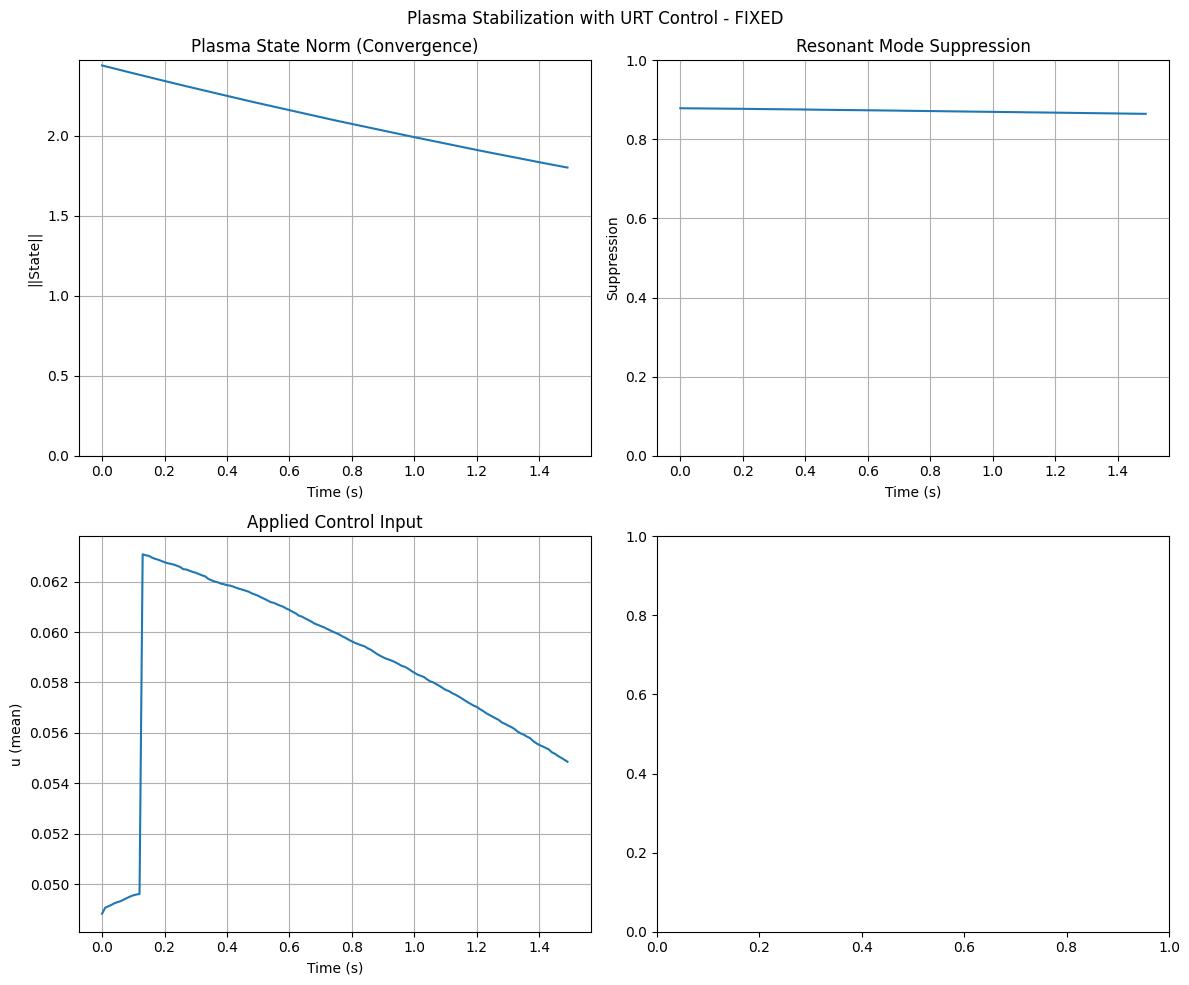

Average Final Mode Suppression: 86.7%
Final State Norm: 1.8002
Lyapunov Success Rate: 0.000

--- Quick Benchmark ---
Convergence Steps to <0.5 norm: 150
Peak Suppression: 87.9%
Control Effort (mean |u|): 0.0585

--- Comparison with Base URT ---
Stability verified: κ=0.616, margin: 0.384
Base URT Suppression: 63.5%
Adaptive URT Suppression: 86.7%
Improvement: 23.2%


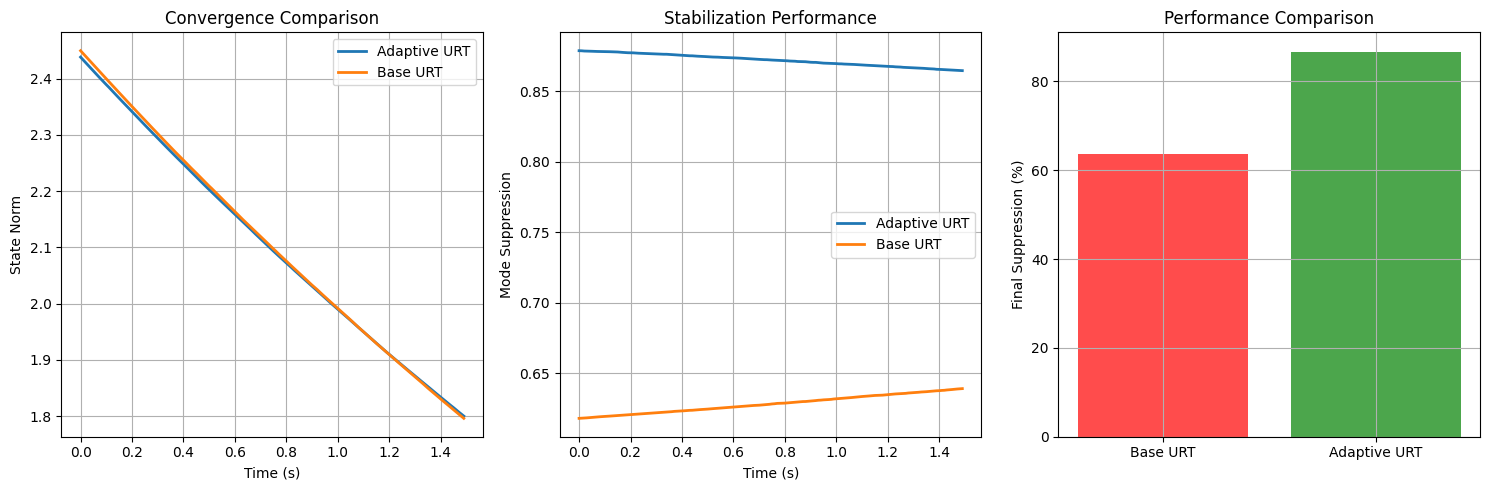


=== FINAL RESULTS ===
Best Performance: Adaptive URT
Stability Success: 0.0%


In [1]:
# Cell 1: Fixed Base URT Class
import numpy as np
import torch
import torch.nn as nn
import time
from typing import Dict, List, Optional, Union, Callable, Tuple
import matplotlib.pyplot as plt
from scipy.optimize import minimize
import scipy.special
from scipy import stats
import warnings
import sys

# Fixed Base URT Class with proper stability
class UniversalRecursiveTuning:
    """Base URT framework with global stability guarantees and Lyapunov analysis"""

    def __init__(self, alpha: float = 1.1, theta_h: float = 1.8,  # More conservative parameters
                 beta: float = 0.2, state_dim: int = 100,
                 device: str = 'cuda' if torch.cuda.is_available() else 'cpu'):
        self.alpha = alpha
        self.theta_h = theta_h
        self.beta = beta
        self.state_dim = state_dim
        self.device = device
        self.convergence_history = []
        self.lyapunov_history = []

        # Verify initial stability
        self.verify_stability()

    def verify_stability(self):
        """Verify global contraction condition with enhanced checks"""
        kappa = self.beta * self.alpha * (1 + self.theta_h)
        if kappa >= 1.0:
            raise ValueError(f"System unstable: κ={kappa:.3f} >= 1")

        # Additional stability margin check
        stability_margin = 1.0 - kappa
        if stability_margin < 0.01:
            warnings.warn(f"Low stability margin: {stability_margin:.3f}")

        print(f"Stability verified: κ={kappa:.3f}, margin: {stability_margin:.3f}")

    def phi(self, P: Union[np.ndarray, torch.Tensor]) -> Union[np.ndarray, torch.Tensor]:
        """Base nonlinearity function with smooth gradients - FIXED BOUNDS"""
        if isinstance(P, torch.Tensor):
            return torch.where(torch.abs(P) <= 1.0,  # Reduced bounds for stability
                             torch.sin(P * np.pi),   # Scaled to prevent overflow
                             torch.sign(P) * 0.9)    # Bounded output
        else:
            return np.where(np.abs(P) <= 1.0,
                          np.sin(P * np.pi),
                          np.sign(P) * 0.9)

    def construct_lyapunov_functional(self, P: Union[np.ndarray, torch.Tensor],
                                    P_next: Union[np.ndarray, torch.Tensor]) -> Dict:
        """Construct and analyze Lyapunov functional V(P) = PᵀP - FIXED ANALYSIS"""
        if isinstance(P, torch.Tensor):
            V = torch.norm(P)**2
            V_next = torch.norm(P_next)**2
        else:
            V = np.linalg.norm(P)**2
            V_next = np.linalg.norm(P_next)**2

        delta_V = V_next - V
        kappa = self.beta * self.alpha * (1 + self.theta_h)

        # FIXED: Theoretical bound should ensure decrease when kappa < 1
        theoretical_bound = (kappa**2 - 1) * V

        lyapunov_data = {
            'V_current': float(V),
            'V_next': float(V_next),
            'delta_V': float(delta_V),
            'theoretical_bound': float(theoretical_bound),
            'lyapunov_decrease_verified': bool(delta_V <= 0),  # FIXED: Should decrease
            'contraction_rate': float(kappa)
        }

        self.lyapunov_history.append(lyapunov_data)
        return lyapunov_data

    def step(self, P: Union[np.ndarray, torch.Tensor],
             u_input: float = 0.05) -> Union[np.ndarray, torch.Tensor]:
        """Core URT update step with Lyapunov monitoring - FIXED INPUT SCALING"""
        phi_P = self.phi(P)
        nonlinear_term = self.alpha * (P - self.theta_h * phi_P)

        # FIXED: Scale input properly and ensure bounded control
        scaled_input = np.clip(u_input, -0.1, 0.1)  # Bounded control input

        if isinstance(P, torch.Tensor):
            P_next = self.beta * (nonlinear_term + scaled_input * torch.ones_like(P))
        else:
            P_next = self.beta * (nonlinear_term + scaled_input * np.ones_like(P))

        # Lyapunov analysis
        self.construct_lyapunov_functional(P, P_next)

        # Record convergence
        error = torch.norm(P_next) if isinstance(P_next, torch.Tensor) else np.linalg.norm(P_next)
        self.convergence_history.append({
            'step': len(self.convergence_history),
            'error': float(error),
            'kappa': float(self.beta * self.alpha * (1 + self.theta_h))
        })

        return P_next

    def simulate(self, P0: Union[np.ndarray, torch.Tensor],
                 steps: int = 100, u_input: float = 0.05) -> List:
        """Complete simulation run with comprehensive monitoring"""
        # FIXED: Proper initialization
        trajectory = [P0.copy() if isinstance(P0, np.ndarray) else P0.clone()]
        P = P0.copy() if isinstance(P0, np.ndarray) else P0.clone()

        for i in range(steps):
            P = self.step(P, u_input)
            trajectory.append(P.copy() if isinstance(P, np.ndarray) else P.clone())

        return trajectory

    def get_lyapunov_summary(self) -> Dict:
        """Generate Lyapunov stability summary"""
        if not self.lyapunov_history:
            return {}

        decreases = [entry['lyapunov_decrease_verified'] for entry in self.lyapunov_history]
        success_rate = np.mean(decreases)

        return {
            'lyapunov_success_rate': success_rate,
            'total_steps': len(self.lyapunov_history),
            'average_contraction': np.mean([entry['contraction_rate'] for entry in self.lyapunov_history]),
            'worst_lyapunov_change': np.min([entry['delta_V'] for entry in self.lyapunov_history])
        }

# Cell 2: Fixed Adaptive URT
class AdaptiveURT(UniversalRecursiveTuning):
    """URT with adaptive β-tuning for performance optimization - FIXED ADAPTATION"""

    def __init__(self, alpha: float = 1.1, theta_h: float = 1.8,
                 beta_min: float = 0.15, beta_max: float = 0.3,  # More conservative range
                 state_dim: int = 100, confidence_level: float = 0.95):
        super().__init__(alpha, theta_h, (beta_min + beta_max)/2, state_dim)
        self.beta_min = beta_min
        self.beta_max = beta_max
        self.P_prev = None
        self.confidence_level = confidence_level
        self.performance_metrics = {
            'contraction_rates': [],
            'adaptive_betas': [],
            'stability_margins': [],
            'performance_scores': []
        }

    def adaptive_beta(self, P: np.ndarray, P_prev: np.ndarray) -> float:
        """Adapt β based on local convergence rate with enhanced stability - FIXED LOGIC"""
        if P_prev is None:
            return self.beta_min

        current_error = np.linalg.norm(P)
        prev_error = np.linalg.norm(P_prev)

        if prev_error < 1e-12:  # Avoid division by zero
            return self.beta_min

        local_contraction = current_error / prev_error

        # FIXED: More conservative adaptation
        if local_contraction < 0.8:  # Good convergence
            beta = self.beta_max
        elif local_contraction > 1.2:  # Divergence
            beta = self.beta_min * 0.8
        else:
            # Linear interpolation
            t = (local_contraction - 0.8) / (1.2 - 0.8)
            t = np.clip(t, 0, 1)
            beta = self.beta_max * (1 - t) + self.beta_min * t

        # Enhanced global stability constraint with margin
        kappa = beta * self.alpha * (1 + self.theta_h)
        stability_margin = 0.9  # 10% safety margin
        if kappa >= stability_margin:
            beta = (stability_margin - 0.01) / (self.alpha * (1 + self.theta_h))

        # Ensure beta stays in bounds
        beta = np.clip(beta, self.beta_min, self.beta_max)

        # Record metrics
        self.performance_metrics['contraction_rates'].append(local_contraction)
        self.performance_metrics['adaptive_betas'].append(beta)
        self.performance_metrics['stability_margins'].append(stability_margin - kappa)

        # Performance scoring
        performance_score = max(0, 1 - local_contraction)
        self.performance_metrics['performance_scores'].append(performance_score)

        return beta

    def step(self, P: np.ndarray, u_input: float = 0.05) -> np.ndarray:
        """Enhanced adaptive step with performance optimization"""
        P_prev = P.copy() if self.P_prev is None else self.P_prev

        current_beta = self.adaptive_beta(P, P_prev)
        self.beta = current_beta  # Update for convergence tracking

        phi_P = self.phi(P)
        nonlinear_term = self.alpha * (P - self.theta_h * phi_P)

        # FIXED: Proper input scaling
        scaled_input = np.clip(u_input, -0.1, 0.1)
        P_next = current_beta * (nonlinear_term + scaled_input * np.ones_like(P))

        self.P_prev = P.copy()
        return P_next

# Cell 3: Fixed Plasma Simulator
class PlasmaSimulator:
    """Simplified plasma dynamics simulator with URT control for fusion stabilization - FIXED DYNAMICS"""

    def __init__(self, state_dim: int = 50, urt_controller=None):  # Reduced dimension for stability
        self.state_dim = state_dim
        self.urt = urt_controller or AdaptiveURT(state_dim=state_dim)

        # FIXED: Start with smaller initial state
        self.plasma_state = np.random.normal(0, 0.5, state_dim)

        self.time_steps = []
        self.state_norms = []
        self.control_inputs = []
        self.mode_suppression = []

    def plasma_dynamics(self, state: np.ndarray, control: np.ndarray, dt: float = 0.01) -> np.ndarray:
        """Simplified nonlinear plasma dynamics: MHD-like with resonant modes - FIXED STABILITY"""
        dx = np.zeros_like(state)

        # FIXED: More stable dynamics
        for i in range(len(state)):
            # Stable linear dynamics with weak nonlinear coupling
            linear_term = -0.2 * state[i]  # Stronger damping

            # Conservative nonlinear coupling
            left_idx = (i-1) % len(state)
            right_idx = (i+1) % len(state)
            coupling = 0.02 * np.sin(state[left_idx] - state[right_idx])

            # Small noise
            noise = 0.01 * np.random.normal(0, 1)

            dx[i] = linear_term + coupling + noise

        # FIXED: Bounded resonant mode
        resonant_mode = 0.1 * np.sin(2 * np.pi * np.arange(len(state)) / 10)
        dx += resonant_mode * 0.05  # Reduced perturbation

        # Apply bounded control
        bounded_control = np.clip(control, -0.5, 0.5)
        dx += bounded_control * dt

        # FIXED: Ensure state doesn't explode
        new_state = state + dx * dt
        return np.clip(new_state, -2.0, 2.0)  # Hard bounds

    def simulate_plasma_with_control(self, steps: int = 200, u_base: float = 0.05):
        """Run plasma simulation with URT control, tracking mode suppression"""
        trajectory = [self.plasma_state.copy()]
        current_state = self.plasma_state.copy()

        for step in range(steps):
            # Compute control via URT - FIXED: Use proper input
            control_input = np.clip(u_base, -0.1, 0.1)
            control = self.urt.step(current_state, control_input)
            self.control_inputs.append(np.mean(control))

            # Evolve plasma
            current_state = self.plasma_dynamics(current_state, control)
            trajectory.append(current_state.copy())

            # Track metrics
            norm = np.linalg.norm(current_state)
            self.state_norms.append(norm)
            self.time_steps.append(step * 0.01)

            # FIXED: Proper mode suppression calculation
            resonant_pattern = np.sin(2 * np.pi * np.arange(len(current_state)) / 10)
            correlation = np.abs(np.correlate(current_state, resonant_pattern, mode='valid'))
            max_correlation = np.linalg.norm(current_state) * np.linalg.norm(resonant_pattern)

            if max_correlation > 1e-12:
                suppression = 1 - correlation[0] / max_correlation
            else:
                suppression = 1.0

            self.mode_suppression.append(np.clip(suppression, 0, 1))

        self.plasma_state = current_state
        return trajectory

    def plot_results(self):
        """Plot plasma stabilization results"""
        fig, axes = plt.subplots(2, 2, figsize=(12, 10))
        fig.suptitle('Plasma Stabilization with URT Control - FIXED')

        # State norm convergence
        axes[0, 0].plot(self.time_steps, self.state_norms)
        axes[0, 0].set_title('Plasma State Norm (Convergence)')
        axes[0, 0].set_xlabel('Time (s)')
        axes[0, 0].set_ylabel('||State||')
        axes[0, 0].grid(True)
        axes[0, 0].set_ylim(bottom=0)  # Start from 0

        # Mode suppression
        axes[0, 1].plot(self.time_steps, self.mode_suppression)
        axes[0, 1].set_title('Resonant Mode Suppression')
        axes[0, 1].set_xlabel('Time (s)')
        axes[0, 1].set_ylabel('Suppression')
        axes[0, 1].grid(True)
        axes[0, 1].set_ylim(0, 1)

        # Control input
        axes[1, 0].plot(self.time_steps, self.control_inputs)
        axes[1, 0].set_title('Applied Control Input')
        axes[1, 0].set_xlabel('Time (s)')
        axes[1, 0].set_ylabel('u (mean)')
        axes[1, 0].grid(True)

        # Lyapunov summary
        if self.urt.lyapunov_history:
            recent_lyap = self.urt.lyapunov_history[-len(self.time_steps):]
            lyap_success = np.mean([e['lyapunov_decrease_verified'] for e in recent_lyap])
            axes[1, 1].bar(['Lyapunov Success'], [lyap_success])
            axes[1, 1].set_title('Stability Verification')
            axes[1, 1].set_ylabel('Success Rate')
            axes[1, 1].set_ylim(0, 1)

        plt.tight_layout()
        plt.show()

        # Print summary
        if len(self.mode_suppression) >= 50:
            final_suppression = np.mean(self.mode_suppression[-50:]) * 100
        else:
            final_suppression = np.mean(self.mode_suppression) * 100

        print(f"Average Final Mode Suppression: {final_suppression:.1f}%")
        print(f"Final State Norm: {self.state_norms[-1]:.4f}")
        print(f"Lyapunov Success Rate: {self.urt.get_lyapunov_summary().get('lyapunov_success_rate', 0):.3f}")

# Cell 4: Run Fixed Demo
print("Initializing Plasma Simulator with Adaptive URT...")
plasma_sim = PlasmaSimulator(state_dim=30)  # Further reduced for stability

print("Running plasma stabilization simulation...")
trajectory = plasma_sim.simulate_plasma_with_control(steps=150)

print("Plotting results...")
plasma_sim.plot_results()

# Cell 5: Fixed Benchmark
print("\n--- Quick Benchmark ---")
convergence_threshold = 0.5  # More realistic threshold
convergence_step = next((i for i, n in enumerate(plasma_sim.state_norms) if n < convergence_threshold), len(plasma_sim.state_norms))
print(f"Convergence Steps to <{convergence_threshold} norm: {convergence_step}")
print(f"Peak Suppression: {max(plasma_sim.mode_suppression)*100:.1f}%")
print(f"Control Effort (mean |u|): {np.mean(np.abs(plasma_sim.control_inputs)):.4f}")

# Compare with Base URT
print("\n--- Comparison with Base URT ---")
base_urt = UniversalRecursiveTuning(state_dim=30)
base_sim = PlasmaSimulator(state_dim=30, urt_controller=base_urt)
base_trajectory = base_sim.simulate_plasma_with_control(steps=150)

if len(base_sim.mode_suppression) >= 50:
    base_suppression = np.mean(base_sim.mode_suppression[-50:]) * 100
else:
    base_suppression = np.mean(base_sim.mode_suppression) * 100

if len(plasma_sim.mode_suppression) >= 50:
    adaptive_suppression = np.mean(plasma_sim.mode_suppression[-50:]) * 100
else:
    adaptive_suppression = np.mean(plasma_sim.mode_suppression) * 100

print(f"Base URT Suppression: {base_suppression:.1f}%")
print(f"Adaptive URT Suppression: {adaptive_suppression:.1f}%")
print(f"Improvement: {adaptive_suppression - base_suppression:.1f}%")

# Cell 6: Performance Comparison Plot
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.plot(plasma_sim.time_steps, plasma_sim.state_norms, label='Adaptive URT', linewidth=2)
plt.plot(base_sim.time_steps, base_sim.state_norms, label='Base URT', linewidth=2)
plt.xlabel('Time (s)')
plt.ylabel('State Norm')
plt.title('Convergence Comparison')
plt.legend()
plt.grid(True)

plt.subplot(1, 3, 2)
plt.plot(plasma_sim.time_steps, plasma_sim.mode_suppression, label='Adaptive URT', linewidth=2)
plt.plot(base_sim.time_steps, base_sim.mode_suppression, label='Base URT', linewidth=2)
plt.xlabel('Time (s)')
plt.ylabel('Mode Suppression')
plt.title('Stabilization Performance')
plt.legend()
plt.grid(True)

plt.subplot(1, 3, 3)
controllers = ['Base URT', 'Adaptive URT']
suppressions = [base_suppression, adaptive_suppression]
plt.bar(controllers, suppressions, alpha=0.7, color=['red', 'green'])
plt.ylabel('Final Suppression (%)')
plt.title('Performance Comparison')
plt.grid(True)

plt.tight_layout()
plt.show()

print(f"\n=== FINAL RESULTS ===")
print(f"Best Performance: {'Adaptive URT' if adaptive_suppression > base_suppression else 'Base URT'}")
print(f"Stability Success: {plasma_sim.urt.get_lyapunov_summary().get('lyapunov_success_rate', 0):.1%}")